In [2]:
from arraylake import Client
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
client = Client()

repo = client.get_repo("artamta/s2s-research")
session = repo.readonly_session("main")

ds = xr.open_zarr(
    session.store,
    group="mean_stddev"
)

ds

<xarray.Dataset> Size: 327GB
Dimensions:                                        (reference_time: 90,
                                                    step: 46, latitude: 361,
                                                    longitude: 720, isobar: 4)
Coordinates:
  * reference_time                                 (reference_time) datetime64[ns] 720B ...
  * step                                           (step) timedelta64[D] 368B ...
  * latitude                                       (latitude) float64 3kB 90....
  * longitude                                      (longitude) float64 6kB 0....
  * isobar                                         (isobar) float64 32B 2e+04...
Data variables: (12/40)
    air_pressure_at_sea_level_stddev               (reference_time, step, latitude, longitude) float32 4GB dask.array<chunksize=(1, 1, 361, 720), meta=np.ndarray>
    air_temperature_at_isobaric_levels_stddev      (reference_time, step, isobar, latitude, longitude) float32 17GB dask.array<chunksize=(1, 1, 1, 361, 720), meta=np.ndarray>
    air_temperature_max_stddev                     (reference_time, step, latitude, longitude) float32 4GB dask.array<chunksize=(1, 1, 361, 720), meta=np.ndarray>
    air_temperature_min_stddev                     (reference_time, step, latitude, longitude) float32 4GB dask.array<chunksize=(1, 1, 361, 720), meta=np.ndarray>
    air_temperature_stddev                         (reference_time, step, latitude, longitude) float32 4GB dask.array<chunksize=(1, 1, 361, 720), meta=np.ndarray>
    air_temperature_min                            (reference_time, step, latitude, longitude) float32 4GB dask.array<chunksize=(1, 1, 361, 720), meta=np.ndarray>
    ...                                             ...
    wind_speed_stddev                              (reference_time, step, latitude, longitude) float32 4GB dask.array<chunksize=(1, 1, 361, 720), meta=np.ndarray>
    wind_speed_at_isobaric_levels_stddev           (reference_time, step, isobar, latitude, longitude) float32 17GB dask.array<chunksize=(1, 1, 1, 361, 720), meta=np.ndarray>
    wind_speed_at_isobaric_levels                  (reference_time, step, isobar, latitude, longitude) float32 17GB dask.array<chunksize=(1, 1, 1, 361, 720), meta=np.ndarray>
    wind_speed_100m                                (reference_time, step, latitude, longitude) float32 4GB dask.array<chunksize=(1, 1, 361, 720), meta=np.ndarray>
    precipitation_amount                           (reference_time, step, latitude, longitude) float32 4GB dask.array<chunksize=(1, 1, 361, 720), meta=np.ndarray>
    wind_speed                                     (reference_time, step, latitude, longitude) float32 4GB dask.array<chunksize=(1, 1, 361, 720), meta=np.ndarray>
Attributes:
    title:        Ensemble Mean and Standard Deviation
    description:  24-hour averaged ensemble mean and ensemble standard deviat...

In [4]:
print(ds.dims)

print("\nVariables:")
for v in ds.data_vars:
    print(v)

FrozenMappingWarningOnValuesAccess({'reference_time': 90, 'step': 46, 'latitude': 361, 'longitude': 720, 'isobar': 4})

Variables:
air_pressure_at_sea_level_stddev
air_temperature_at_isobaric_levels_stddev
air_temperature_max_stddev
air_temperature_min_stddev
air_temperature_stddev
air_temperature_min
air_temperature_at_isobaric_levels
air_temperature
air_pressure_at_sea_level
air_temperature_max
eastward_wind_100m_stddev
eastward_wind_at_isobaric_levels
eastward_wind_stddev
geopotential_thickness_stddev
eastward_wind
eastward_wind_at_isobaric_levels_stddev
eastward_wind_100m
geopotential_height_at_isobaric_levels_stddev
geopotential_height_at_isobaric_levels
northward_wind_at_isobaric_levels
northward_wind_at_isobaric_levels_stddev
northward_wind_stddev
northward_wind_100m
geopotential_thickness
northward_wind_100m_stddev
northward_wind
specific_humidity_at_isobaric_levels
specific_humidity_at_isobaric_levels_stddev
surface_downwelling_shortwave_flux_stddev
surface_downwelling_shortwa

In [5]:
temperature_vars = [v for v in ds.data_vars if "temperature" in v]
wind_vars = [v for v in ds.data_vars if "wind" in v]
pressure_vars = [v for v in ds.data_vars if "pressure" in v]

print(temperature_vars)
print(wind_vars)
print(pressure_vars)

['air_temperature_at_isobaric_levels_stddev', 'air_temperature_max_stddev', 'air_temperature_min_stddev', 'air_temperature_stddev', 'air_temperature_min', 'air_temperature_at_isobaric_levels', 'air_temperature', 'air_temperature_max']
['eastward_wind_100m_stddev', 'eastward_wind_at_isobaric_levels', 'eastward_wind_stddev', 'eastward_wind', 'eastward_wind_at_isobaric_levels_stddev', 'eastward_wind_100m', 'northward_wind_at_isobaric_levels', 'northward_wind_at_isobaric_levels_stddev', 'northward_wind_stddev', 'northward_wind_100m', 'northward_wind_100m_stddev', 'northward_wind', 'wind_speed_100m_stddev', 'wind_speed_stddev', 'wind_speed_at_isobaric_levels_stddev', 'wind_speed_at_isobaric_levels', 'wind_speed_100m', 'wind_speed']
['air_pressure_at_sea_level_stddev', 'air_pressure_at_sea_level']


In [6]:
india = ds.sel(
    latitude=slice(40,5),
    longitude=slice(65,100)
)

india

<xarray.Dataset> Size: 6GB
Dimensions:                                        (reference_time: 90,
                                                    step: 46, latitude: 71,
                                                    longitude: 71, isobar: 4)
Coordinates:
  * reference_time                                 (reference_time) datetime64[ns] 720B ...
  * step                                           (step) timedelta64[D] 368B ...
  * latitude                                       (latitude) float64 568B 40...
  * longitude                                      (longitude) float64 568B 6...
  * isobar                                         (isobar) float64 32B 2e+04...
Data variables: (12/40)
    air_pressure_at_sea_level_stddev               (reference_time, step, latitude, longitude) float32 83MB dask.array<chunksize=(1, 1, 71, 71), meta=np.ndarray>
    air_temperature_at_isobaric_levels_stddev      (reference_time, step, isobar, latitude, longitude) float32 334MB dask.array<chunksize=(1, 1, 1, 71, 71), meta=np.ndarray>
    air_temperature_max_stddev                     (reference_time, step, latitude, longitude) float32 83MB dask.array<chunksize=(1, 1, 71, 71), meta=np.ndarray>
    air_temperature_min_stddev                     (reference_time, step, latitude, longitude) float32 83MB dask.array<chunksize=(1, 1, 71, 71), meta=np.ndarray>
    air_temperature_stddev                         (reference_time, step, latitude, longitude) float32 83MB dask.array<chunksize=(1, 1, 71, 71), meta=np.ndarray>
    air_temperature_min                            (reference_time, step, latitude, longitude) float32 83MB dask.array<chunksize=(1, 1, 71, 71), meta=np.ndarray>
    ...                                             ...
    wind_speed_stddev                              (reference_time, step, latitude, longitude) float32 83MB dask.array<chunksize=(1, 1, 71, 71), meta=np.ndarray>
    wind_speed_at_isobaric_levels_stddev           (reference_time, step, isobar, latitude, longitude) float32 334MB dask.array<chunksize=(1, 1, 1, 71, 71), meta=np.ndarray>
    wind_speed_at_isobaric_levels                  (reference_time, step, isobar, latitude, longitude) float32 334MB dask.array<chunksize=(1, 1, 1, 71, 71), meta=np.ndarray>
    wind_speed_100m                                (reference_time, step, latitude, longitude) float32 83MB dask.array<chunksize=(1, 1, 71, 71), meta=np.ndarray>
    precipitation_amount                           (reference_time, step, latitude, longitude) float32 83MB dask.array<chunksize=(1, 1, 71, 71), meta=np.ndarray>
    wind_speed                                     (reference_time, step, latitude, longitude) float32 83MB dask.array<chunksize=(1, 1, 71, 71), meta=np.ndarray>
Attributes:
    title:        Ensemble Mean and Standard Deviation
    description:  24-hour averaged ensemble mean and ensemble standard deviat...

In [7]:
india.air_temperature

<xarray.DataArray 'air_temperature' (reference_time: 90, step: 46,
                                     latitude: 71, longitude: 71)> Size: 83MB
dask.array<getitem, shape=(90, 46, 71, 71), dtype=float32, chunksize=(1, 1, 71, 71), chunktype=numpy.ndarray>
Coordinates:
  * reference_time  (reference_time) datetime64[ns] 720B 2026-01-01 ... 2026-...
  * step            (step) timedelta64[D] 368B 1 days 2 days ... 45 days 46 days
  * latitude        (latitude) float64 568B 40.0 39.5 39.0 38.5 ... 6.0 5.5 5.0
  * longitude       (longitude) float64 568B 65.0 65.5 66.0 ... 99.0 99.5 100.0
Attributes:
    standard_name:  air_temperature
    units:          K
    long_name:      2m air temperature
    description:    Air temperature at 2 metres above the surface. 24-hour en...

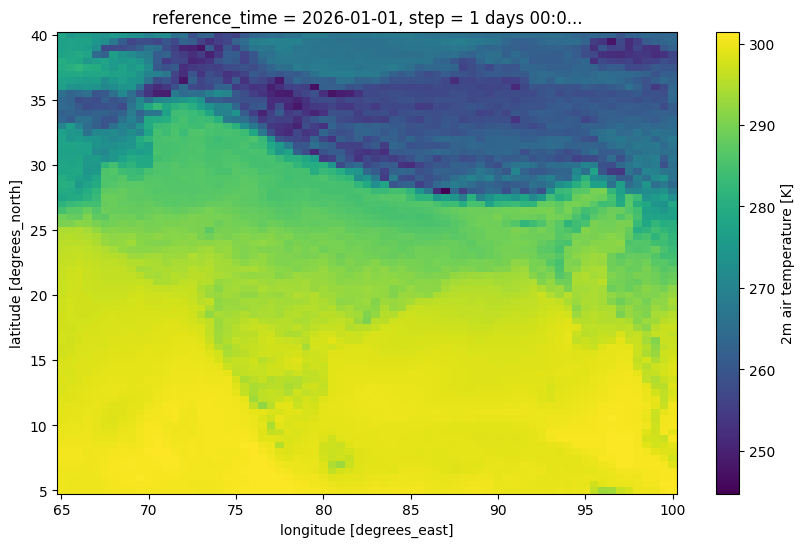

In [9]:
india.air_temperature.isel(
    reference_time=0,
    step=0
).plot(figsize=(10,6))

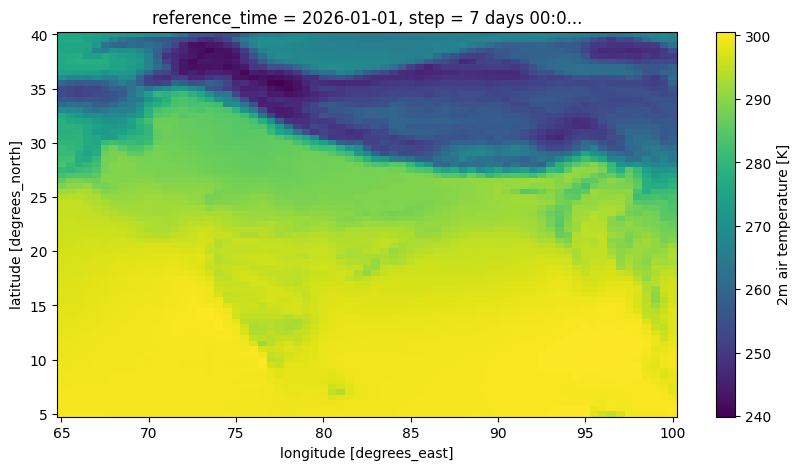

In [10]:
india.air_temperature.isel(
    reference_time=0,
    step=6
).plot(figsize=(10,5))

In [11]:
india_temp = (
    india.air_temperature
    .mean(dim=["latitude","longitude"])
)

india_temp

<xarray.DataArray 'air_temperature' (reference_time: 90, step: 46)> Size: 17kB
dask.array<mean_agg-aggregate, shape=(90, 46), dtype=float32, chunksize=(1, 1), chunktype=numpy.ndarray>
Coordinates:
  * reference_time  (reference_time) datetime64[ns] 720B 2026-01-01 ... 2026-...
  * step            (step) timedelta64[D] 368B 1 days 2 days ... 45 days 46 days
Attributes:
    standard_name:  air_temperature
    units:          K
    long_name:      2m air temperature
    description:    Air temperature at 2 metres above the surface. 24-hour en...

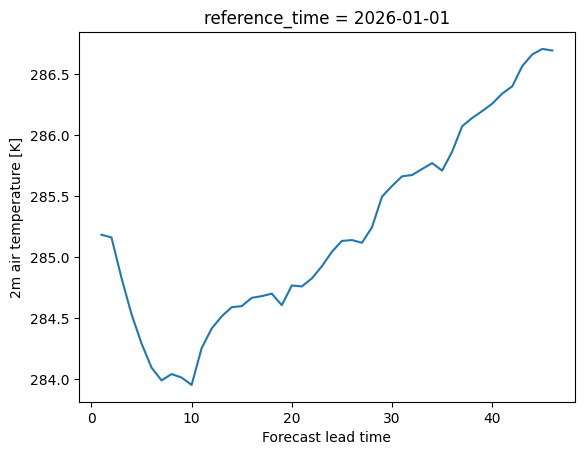

In [12]:
india_temp.isel(reference_time=0).plot()

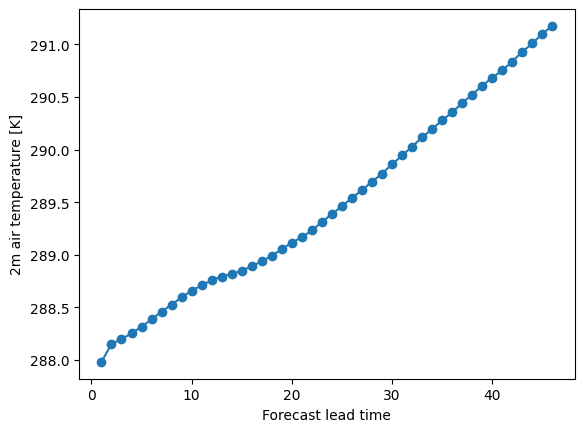

In [13]:
lead_mean = india_temp.mean("reference_time")

lead_mean.plot(marker="o")

In [14]:
anom = xr.open_zarr(
    session.store,
    group="anomalies"
)

anom

<xarray.Dataset> Size: 69GB
Dimensions:                             (reference_time: 90, step: 46,
                                         latitude: 361, longitude: 720,
                                         isobar: 4)
Coordinates:
  * reference_time                      (reference_time) datetime64[ns] 720B ...
  * step                                (step) timedelta64[D] 368B 1 days ......
  * latitude                            (latitude) float64 3kB 90.0 ... -90.0
  * longitude                           (longitude) float64 6kB 0.0 ... 359.5
  * isobar                              (isobar) float64 32B 2e+04 ... 1e+05
Data variables:
    precipitation_amount                (reference_time, step, latitude, longitude) float32 4GB dask.array<chunksize=(1, 1, 361, 720), meta=np.ndarray>
    air_pressure_at_sea_level           (reference_time, step, latitude, longitude) float32 4GB dask.array<chunksize=(1, 1, 361, 720), meta=np.ndarray>
    geopotential_height                 (reference_time, step, isobar, latitude, longitude) float32 17GB dask.array<chunksize=(1, 1, 1, 361, 720), meta=np.ndarray>
    geopotential_thickness              (reference_time, step, latitude, longitude) float32 4GB dask.array<chunksize=(1, 1, 361, 720), meta=np.ndarray>
    surface_downwelling_shortwave_flux  (reference_time, step, latitude, longitude) float32 4GB dask.array<chunksize=(1, 1, 361, 720), meta=np.ndarray>
    wind_speed_100m                     (reference_time, step, latitude, longitude) float32 4GB dask.array<chunksize=(1, 1, 361, 720), meta=np.ndarray>
    air_temperature_min                 (reference_time, step, latitude, longitude) float32 4GB dask.array<chunksize=(1, 1, 361, 720), meta=np.ndarray>
    air_temperature_max                 (reference_time, step, latitude, longitude) float32 4GB dask.array<chunksize=(1, 1, 361, 720), meta=np.ndarray>
    wind_speed                          (reference_time, step, latitude, longitude) float32 4GB dask.array<chunksize=(1, 1, 361, 720), meta=np.ndarray>
    temperature                         (reference_time, step, isobar, latitude, longitude) float32 17GB dask.array<chunksize=(1, 1, 1, 361, 720), meta=np.ndarray>
Attributes:
    title:        Anomalies Relative to Climatology
    description:  Forecast anomalies (deviations from the ERA5 1991-2020 clim...

In [15]:
india_anom = anom.sel(
    latitude=slice(40,5),
    longitude=slice(65,100)
)

In [18]:
print(india_anom)

<xarray.Dataset> Size: 1GB
Dimensions:                             (reference_time: 90, step: 46,
                                         latitude: 71, longitude: 71, isobar: 4)
Coordinates:
  * reference_time                      (reference_time) datetime64[ns] 720B ...
  * step                                (step) timedelta64[D] 368B 1 days ......
  * latitude                            (latitude) float64 568B 40.0 ... 5.0
  * longitude                           (longitude) float64 568B 65.0 ... 100.0
  * isobar                              (isobar) float64 32B 2e+04 ... 1e+05
Data variables:
    precipitation_amount                (reference_time, step, latitude, longitude) float32 83MB dask.array<chunksize=(1, 1, 71, 71), meta=np.ndarray>
    air_pressure_at_sea_level           (reference_time, step, latitude, longitude) float32 83MB dask.array<chunksize=(1, 1, 71, 71), meta=np.ndarray>
    geopotential_height                 (reference_time, step, isobar, latitude, longitude) fl

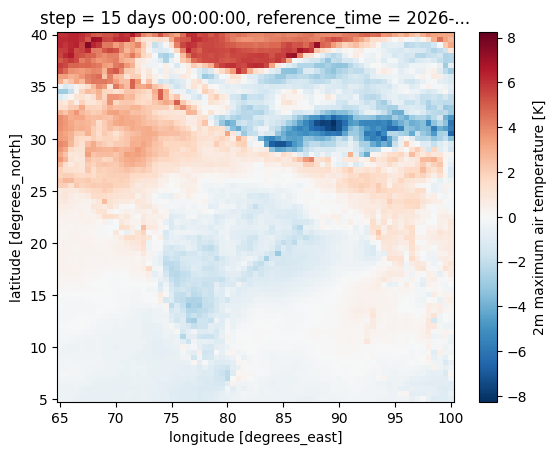

In [19]:
india_anom["air_temperature_max"].isel(
    reference_time=0,
    step=14
).plot()

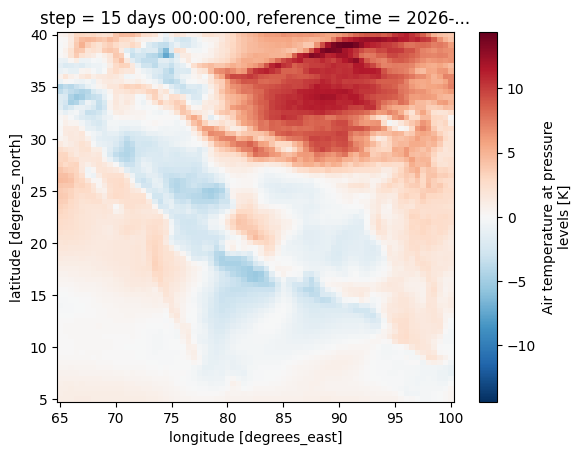

In [20]:
india_anom["temperature"].isel(
    reference_time=0,
    step=14,
    isobar=3
).plot()

In [21]:
tanom = (
    india_anom["air_temperature_max"]
    .mean(["latitude","longitude"])
)

In [22]:
lead_anom = tanom.mean("reference_time")

Text(0.5, 1.0, 'Mean India Temperature Anomaly vs Lead Time')

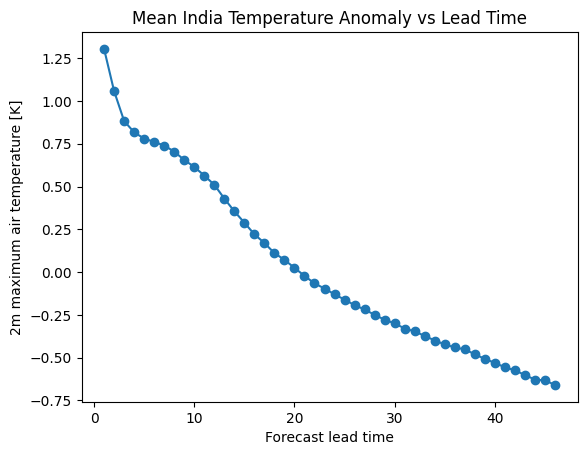

In [23]:
lead_anom.plot(marker="o")
plt.title("Mean India Temperature Anomaly vs Lead Time")

In [24]:
spread = (
    india["air_temperature_stddev"]
    .mean(["latitude","longitude"])
)

anom = (
    india_anom["air_temperature_max"]
    .mean(["latitude","longitude"])
)

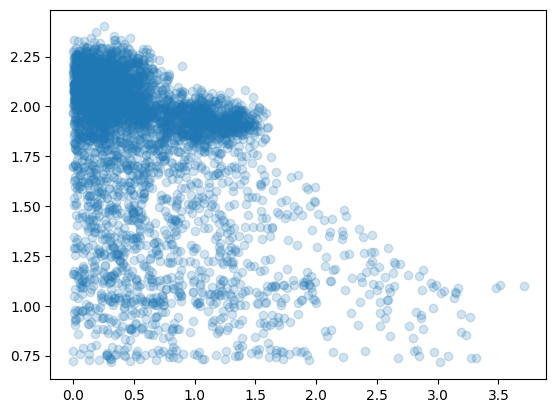

In [25]:
plt.scatter(
    np.abs(anom.values.flatten()),
    spread.values.flatten(),
    alpha=0.2
)

In [26]:
prob = xr.open_zarr(
    session.store,
    group="probabilities"
)

print(prob)
list(prob.data_vars)

<xarray.Dataset> Size: 362GB
Dimensions:                                                 (
                                                             reference_time: 90,
                                                             step: 46,
                                                             latitude: 361,
                                                             longitude: 720)
Coordinates:
  * reference_time                                          (reference_time) datetime64[ns] 720B ...
  * step                                                    (step) timedelta64[D] 368B ...
  * latitude                                                (latitude) float64 3kB ...
  * longitude                                               (longitude) float64 6kB ...
Data variables: (12/84)
    air_pressure_at_sea_level_prob_abnorm                   (reference_time, step, latitude, longitude) float32 4GB dask.array<chunksize=(1, 1, 361, 720), meta=np.ndarray>
    air_pressure_at_sea_leve

['air_pressure_at_sea_level_prob_abnorm',
 'air_pressure_at_sea_level_prob_lower_tercile',
 'air_pressure_at_sea_level_prob_lower_quintile',
 'air_pressure_at_sea_level_prob_upper_decile',
 'air_temperature_max_prob_abnorm',
 'air_pressure_at_sea_level_prob_upper_quintile',
 'air_temperature_max_prob_upper_quintile',
 'air_temperature_min_prob_lower_decile',
 'air_temperature_max_prob_upper_tercile',
 'air_temperature_min_prob_lower_quintile',
 'air_temperature_max_prob_lower_tercile',
 'air_temperature_max_prob_lower_quintile',
 'air_pressure_at_sea_level_prob_upper_tercile',
 'air_temperature_max_prob_upper_decile',
 'air_temperature_min_prob_lower_tercile',
 'air_temperature_prob_lower_decile',
 'air_temperature_prob_lower_quintile',
 'air_temperature_min_prob_abnorm',
 'air_temperature_min_prob_upper_tercile',
 'air_temperature_prob_lower_tercile',
 'air_pressure_at_sea_level_prob_lower_decile',
 'air_temperature_max_prob_lower_decile',
 'air_temperature_min_prob_upper_decile',
 'a

In [27]:
prob_india = prob.sel(
    latitude=slice(40,5),
    longitude=slice(65,100)
)